In [2]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\jeane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# For manipulating file paths
import os

# For manipulating file paths
import warnings
warnings.filterwarnings("ignore")

# Libraries for creating data plots
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn or scikit-learn is one of the most popular Machine Learning libraries in python
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [12]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\jeane\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import kagglehub
data_path = kagglehub.dataset_download("lumaatabbaa/vr-eyes-emotions-dataset-vreed")
# Vérifier les fichiers disponibles
print(os.listdir(data_path))

100%|███████████████████████████████████████████████████████████████████████████████| 555M/555M [01:13<00:00, 7.92MB/s]

Extracting files...


['01 Dataset Summary', '02 Stimuli Selection', '03 Self-Reported Questionnaires', '04 Eye Tracking Data', '05 ECG-GSR Data', 'Supporting Documents']


In [15]:
import pandas as pd
from pathlib import Path

BASE = Path(r'C:\Users\jeane\Documents\Psychologie\VR Eyes Emotions Dataset\data')

# Labels
df_labels = pd.read_excel(BASE / 'Post Exposure Ratings.xlsx')

# Eye Tracking
df_eye = pd.read_csv(BASE /'EyeTracking_FeaturesExtracted.csv')

# ECG & GSR
df_ecg = pd.read_csv(BASE / 'ECG_FeaturesExtracted.csv')
df_gsr = pd.read_csv(BASE/ 'GSR_FeaturesExtracted.csv')

print('Labels :', df_labels.shape)
print('Eye    :', df_eye.shape)
print('ECG    :', df_ecg.shape)
print('GSR    :', df_gsr.shape)

Labels : (408, 27)
Eye    : (312, 50)
ECG    : (312, 19)
GSR    : (312, 9)


In [16]:
print("=== LABELS ===")
print(df_labels.columns.tolist())

print("\n=== EYE TRACKING ===")
print(df_eye.columns.tolist())

print("\n=== ECG ===")
print(df_ecg.columns.tolist())

print("\n=== GSR ===")
print(df_gsr.columns.tolist())

=== LABELS ===
['ID', 'Trial_Num', 'Quad_Cat', 'Arousal_Cat', 'Valence_Cat', 'Str_Code', 'Num_Code', 'POST_Valence', 'POST_Arousal', 'POST_Joy', 'POST_Happy', 'POST_Calmness', 'POST_Relaxation', 'POST_Anger', 'POST_Disgust', 'POST_Fear', 'POST_Anxiousness', 'POST_Sadness', 'POST_Dizzy', 'POST_PQ1', 'POST_PQ2', 'POST_PQ3', 'POST_PQ4', 'POST_PQ5', 'POST_PQ6', 'POST_PQ7', 'POST_PQ8']

=== EYE TRACKING ===
['Quad_Cat', 'Num_of_Fixations', 'Mean_Fixation_Duration', 'SD_Fixation_Duration', 'Skew_Fixation_Duration', 'Max_Fixation_Duration', 'First_Fixation_Duration', 'Num_of_Saccade', 'Mean_Saccade_Duration', 'SD_Saccade_Duration', 'Skew_Saccade_Duration', 'Max_Saccade_Duration', 'Mean_Saccade_Amplitude', 'SD_Saccade_Amplitude', 'Skew_Saccade_Amplitude', 'Max_Saccade_Amplitude', 'Mean_Saccade_Direction', 'SD_Saccade_Direction', 'Skew_Saccade_Direction', 'Max_Saccade_Direction', 'Mean_Saccade_Length', 'SD_Saccade_Length', 'Skew_Saccade_Length', 'Max_Saccade_Length', 'Num_of_Blink', 'Mean_Blink

In [18]:
print("=== Valeurs uniques Quad_Cat ===")
print("Labels  :", df_labels['Quad_Cat'].unique())
print("Eye     :", df_eye['Quad_Cat'].unique())
print("ECG     :", df_ecg['Quad_Cat'].unique())
print("GSR     :", df_gsr['Quad_Cat'].unique())

=== Valeurs uniques Quad_Cat ===
Labels  : [2 0 3 1]
Eye     : [1 0 3 2]
ECG     : [1 0 3 2]
GSR     : [1 0 3 2]


In [19]:
print("\n=== Nombre de lignes par Quad_Cat ===")
print("Labels  :", df_labels['Quad_Cat'].value_counts())
print("Eye     :", df_eye['Quad_Cat'].value_counts())


=== Nombre de lignes par Quad_Cat ===
Labels  : Quad_Cat
2    102
0    102
3    102
1    102
Name: count, dtype: int64
Eye     : Quad_Cat
1    78
0    78
3    78
2    78
Name: count, dtype: int64


In [50]:
df_features = pd.concat([
    df_eye,
    df_ecg.drop(columns=['Quad_Cat']),
    df_gsr.drop(columns=['Quad_Cat'])
], axis=1)


In [51]:
print("Features fusionnées :", df_features.shape)
print("Valeurs manquantes  :", df_features.isnull().sum().sum())

Features fusionnées : (312, 82)
Valeurs manquantes  : 96


In [52]:
# Vérification : Quad_Cat identique dans les 3 fichiers ?
print("\nQuad_Cat identique dans Eye et ECG :", (df_eye['Quad_Cat'] == df_ecg['Quad_Cat']).all())
print("Quad_Cat identique dans Eye et GSR :", (df_eye['Quad_Cat'] == df_gsr['Quad_Cat']).all())


Quad_Cat identique dans Eye et ECG : True
Quad_Cat identique dans Eye et GSR : True


In [53]:
# Fusion features + labels sur Quad_Cat
df = df_labels.merge(df_features, on='Quad_Cat', how='inner')

print("Dataset final :", df.shape)
print("\nDistribution Quad_Cat :")
print(df['Quad_Cat'].value_counts().sort_index())

Dataset final : (31824, 108)

Distribution Quad_Cat :
Quad_Cat
0    7956
1    7956
2    7956
3    7956
Name: count, dtype: int64


In [54]:
print("\nDistribution Arousal_Cat :")
print(df['Arousal_Cat'].value_counts())

print("\nDistribution Valence_Cat :")
print(df['Valence_Cat'].value_counts())



Distribution Arousal_Cat :
Arousal_Cat
0    15912
1    15912
Name: count, dtype: int64

Distribution Valence_Cat :
Valence_Cat
0    15912
1    15912
Name: count, dtype: int64


In [55]:
# Option 1 : utiliser UNIQUEMENT les features (312 lignes) avec Quad_Cat comme label
# C'est le dataset principal pour la classification

X = df_features.drop(columns=['Quad_Cat'])
y = df_features['Quad_Cat']

print("X (features) :", X.shape)
print("y (labels)    :", y.shape)
print("\nDistribution des classes :")
print(y.value_counts().sort_index())

# Option 2 : utiliser les labels agrégés par Quad_Cat depuis df_labels
labels_agg = df_labels.groupby('Quad_Cat')[['Arousal_Cat', 'Valence_Cat',
                                             'POST_Valence', 'POST_Arousal']].mean()
print("\nLabels moyens par Quad_Cat :")
print(labels_agg)

X (features) : (312, 81)
y (labels)    : (312,)

Distribution des classes :
Quad_Cat
0    78
1    78
2    78
3    78
Name: count, dtype: int64

Labels moyens par Quad_Cat :
          Arousal_Cat  Valence_Cat  POST_Valence  POST_Arousal
Quad_Cat                                                      
0                 1.0          1.0      6.464646      3.797980
1                 0.0          1.0      6.484848      2.515152
2                 0.0          0.0      2.460784      3.519608
3                 1.0          0.0      4.297030      5.980198


In [56]:
# ============================================
# STATISTIQUES DESCRIPTIVES — VREED
# ============================================

# 1. Types de variables
print("=== TYPES DE VARIABLES ===")
print(X.dtypes.value_counts())
print()

# 2. Aperçu des types colonne par colonne
print("=== APERÇU PAR COLONNE ===")
print(X.dtypes)

=== TYPES DE VARIABLES ===
float64    69
int64      12
Name: count, dtype: int64

=== APERÇU PAR COLONNE ===
Num_of_Fixations          float64
Mean_Fixation_Duration    float64
SD_Fixation_Duration      float64
Skew_Fixation_Duration    float64
Max_Fixation_Duration       int64
                           ...   
Number of Peaks           float64
Number of Valleys         float64
Ratio                     float64
participant_idx             int64
video_idx                   int64
Length: 81, dtype: object


In [57]:
# 3. Valeurs manquantes
print("=== VALEURS MANQUANTES ===")
missing = X.isnull().sum()
missing_pct = (missing / len(X) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0]

if missing_df.empty:
    print("Aucune valeur manquante ✓")
else:
    print(missing_df)

=== VALEURS MANQUANTES ===
                     Manquantes  Pourcentage
Mean_Blink_Duration          11         3.53
SD_Blink_Duration            37        11.86
Skew_Blink_Duration          37        11.86
Max_Blink_Duration           11         3.53


In [58]:
# Imputation des valeurs manquantes par la médiane
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# Vérification
print("Valeurs manquantes avant :", X.isnull().sum().sum())
print("Valeurs manquantes après :", X_imputed.isnull().sum().sum())
print("Shape                    :", X_imputed.shape)

Valeurs manquantes avant : 96
Valeurs manquantes après : 0
Shape                    : (312, 81)


In [60]:
# Détection de valeurs aberrantes (méthode IQR)
print("=== VALEURS ABERRANTES (IQR) ===")
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).sum()
outliers_pct = (outliers / len(X) * 100).round(2)
outliers_df = pd.DataFrame({'Outliers': outliers, 'Pourcentage': outliers_pct})
print(outliers_df[outliers_df['Outliers'] > 0].sort_values('Pourcentage', ascending=False).head(20))

=== VALEURS ABERRANTES (IQR) ===
                         Outliers  Pourcentage
MaxRR                          46        14.74
MedianRR                       45        14.42
MeanRR                         42        13.46
VLF                            38        12.18
MinRR                          37        11.86
Max_Microsac_Dir               34        10.90
HF                             34        10.90
LF                             34        10.90
Max_Blink_Duration             33        10.58
Mean_Microsac_V_Amp            31         9.94
Mean_Blink_Duration            31         9.94
SD_Blink_Duration              29         9.29
Max_Saccade_Direction          27         8.65
First_Fixation_Duration        24         7.69
Pnn50                          23         7.37
Variance                       22         7.05
pnn20                          21         6.73
Num_of_Microsac                20         6.41
Num_of_Blink                   19         6.09
Pnn50pnn20                 

In [64]:
import numpy as np

X_clean = X_imputed.copy()

for col in X_clean.columns:
    Q1    = X_clean[col].quantile(0.25)
    Q3    = X_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X_clean[col] = np.clip(X_clean[col].values, lower, upper)

print(f"Shape : {X_clean.shape}")
print("Nettoyage terminé ✓")

Shape : (312, 81)
Nettoyage terminé ✓


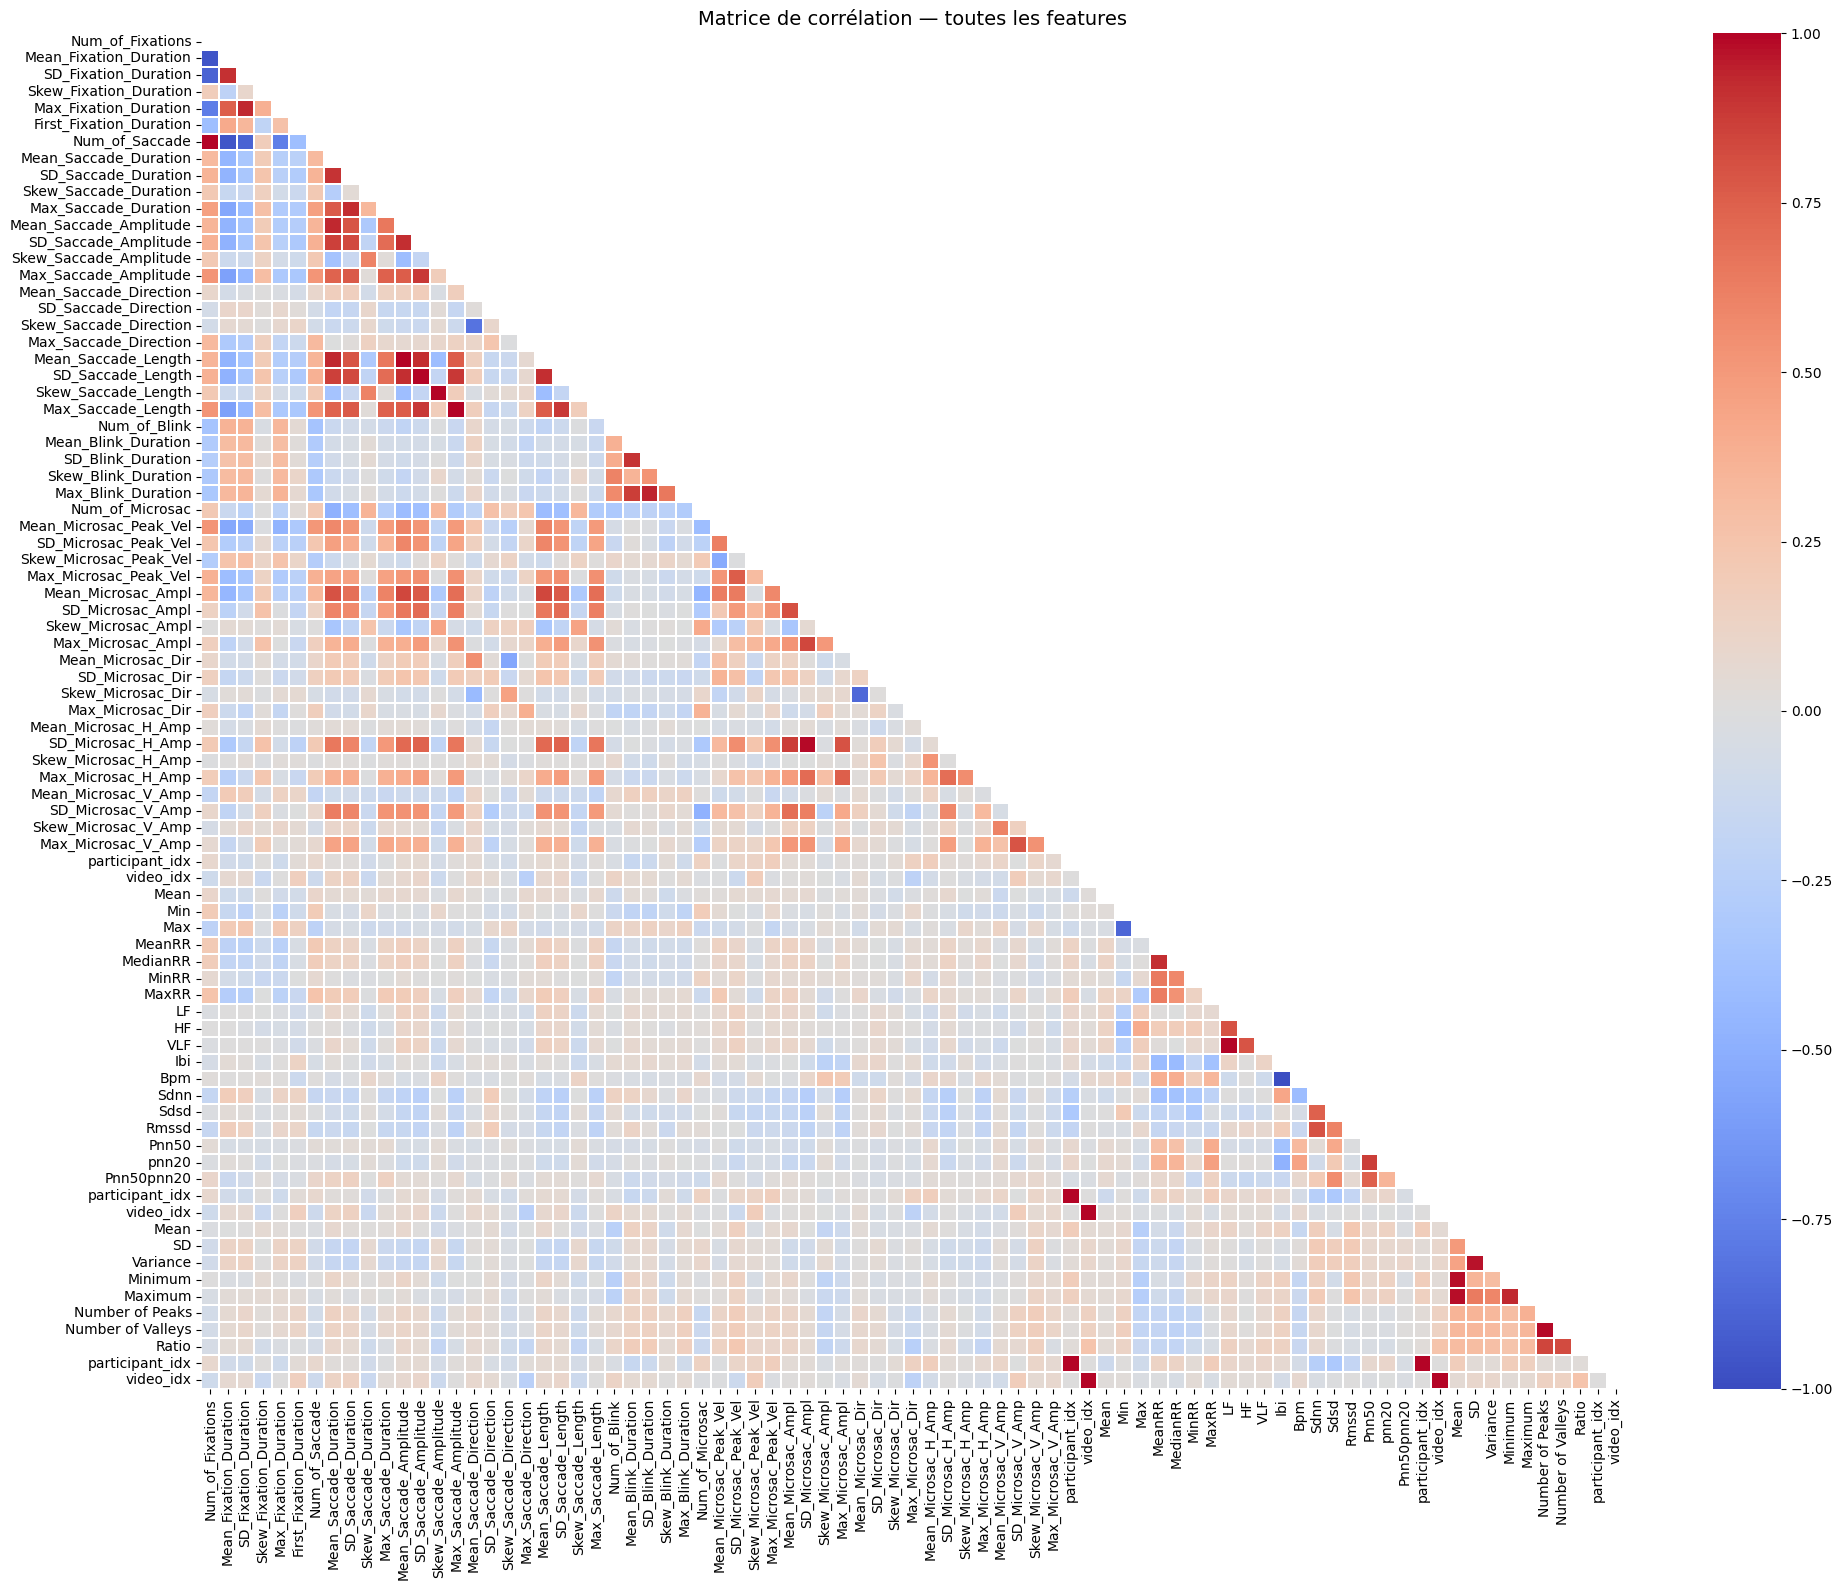

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. MATRICE DE CORRÉLATION — toutes les features
# ============================================
plt.figure(figsize=(20, 16))
corr_matrix = X_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.3,
            xticklabels=True, yticklabels=True)
plt.title('Matrice de corrélation — toutes les features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

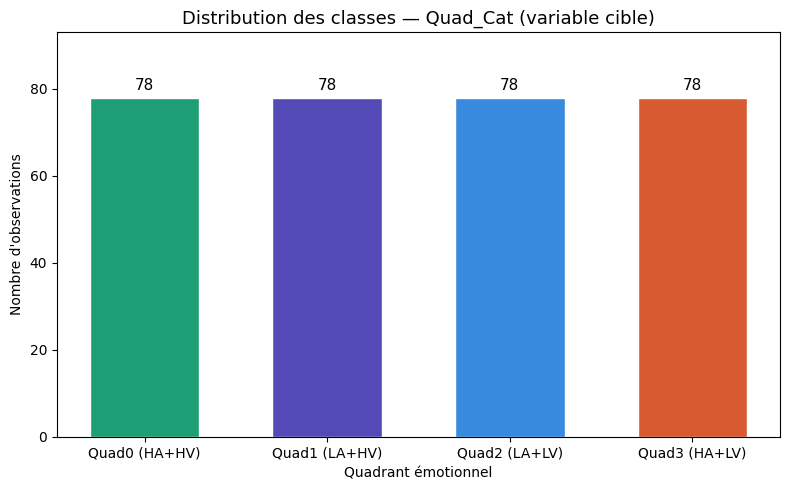

Distribution :
  Quad0 (HA+HV) : 78 observations (25.0%)
  Quad1 (LA+HV) : 78 observations (25.0%)
  Quad2 (LA+LV) : 78 observations (25.0%)
  Quad3 (HA+LV) : 78 observations (25.0%)


In [68]:
plt.figure(figsize=(8, 5))

quad_labels = {0: 'Quad0 (HA+HV)', 1: 'Quad1 (LA+HV)',
               2: 'Quad2 (LA+LV)', 3: 'Quad3 (HA+LV)'}
colors = ['#1d9e75', '#534ab7', '#378add', '#d85a30']

counts = y.value_counts().sort_index()
bars = plt.bar(
    [quad_labels[i] for i in counts.index],
    counts.values,
    color=colors,
    edgecolor='white',
    width=0.6
)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=11)

plt.title('Distribution des classes — Quad_Cat (variable cible)', fontsize=13)
plt.ylabel('Nombre d\'observations')
plt.xlabel('Quadrant émotionnel')
plt.ylim(0, counts.max() + 15)
plt.tight_layout()
plt.savefig('distribution_y.png', dpi=150)
plt.show()

print("Distribution :")
for k, v in counts.items():
    print(f"  {quad_labels[k]} : {v} observations ({v/len(y)*100:.1f}%)")

In [89]:
# Vérifier les colonnes parasites
print("Colonnes à supprimer :", [c for c in X_final.columns if c in ['video_idx', 'participant_idx']])

# Supprimer les colonnes parasites
cols_to_drop = ['video_idx', 'participant_idx']
X_final = X_final.drop(columns=[c for c in cols_to_drop if c in X_final.columns])

print("Shape après nettoyage :", X_final.shape)
print("Colonnes :", X_final.columns.tolist())

Colonnes à supprimer : ['participant_idx', 'video_idx', 'participant_idx', 'video_idx', 'participant_idx', 'video_idx']
Shape après nettoyage : (312, 75)
Colonnes : ['Num_of_Fixations', 'Mean_Fixation_Duration', 'SD_Fixation_Duration', 'Skew_Fixation_Duration', 'Max_Fixation_Duration', 'First_Fixation_Duration', 'Num_of_Saccade', 'Mean_Saccade_Duration', 'SD_Saccade_Duration', 'Skew_Saccade_Duration', 'Max_Saccade_Duration', 'Mean_Saccade_Amplitude', 'SD_Saccade_Amplitude', 'Skew_Saccade_Amplitude', 'Max_Saccade_Amplitude', 'Mean_Saccade_Direction', 'SD_Saccade_Direction', 'Skew_Saccade_Direction', 'Max_Saccade_Direction', 'Mean_Saccade_Length', 'SD_Saccade_Length', 'Skew_Saccade_Length', 'Max_Saccade_Length', 'Num_of_Blink', 'Mean_Blink_Duration', 'SD_Blink_Duration', 'Skew_Blink_Duration', 'Max_Blink_Duration', 'Num_of_Microsac', 'Mean_Microsac_Peak_Vel', 'SD_Microsac_Peak_Vel', 'Skew_Microsac_Peak_Vel', 'Max_Microsac_Peak_Vel', 'Mean_Microsac_Ampl', 'SD_Microsac_Ampl', 'Skew_Microsa

In [92]:
# S'assurer que tout est propre avant de lancer
cols_to_drop = ['video_idx', 'participant_idx']

X_final = X_clean.drop(columns=[c for c in cols_to_drop if c in X_clean.columns])

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_final : {X_final.shape}")
print(f"Train   : {X_train.shape} | Test : {X_test.shape}")

X_final : (312, 75)
Train   : (249, 75) | Test : (63, 75)


In [98]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1. ENTRAÎNEMENT DES MODÈLES
# ============================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)

# Top 3 features RF
top3 = pd.Series(rf.feature_importances_, index=X_final.columns) \
         .sort_values(ascending=False).head(3).index.tolist()
print("Top 3 features :", top3)

rf_aux = RandomForestClassifier(n_estimators=100, random_state=42)
rf_aux.fit(X_train_scaled, y_train)
top3_svm = pd.Series(rf_aux.feature_importances_, index=X_final.columns) \
             .sort_values(ascending=False).head(3).index.tolist()
X_train_top3 = X_train[top3]
X_test_top3  = X_test[top3]

scaler_svm       = StandardScaler()
X_train_top3_svm = scaler_svm.fit_transform(X_train[top3_svm])
X_test_top3_svm  = scaler_svm.transform(X_test[top3_svm])

rf_top3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top3.fit(X_train_top3, y_train)

svm_top3 = SVC(kernel='rbf', random_state=42)
svm_top3.fit(X_train_top3_svm, y_train)

y_pred_rf    = rf.predict(X_test)
y_pred_svm   = svm.predict(X_test_scaled)
y_pred_top3  = rf_top3.predict(X_test_top3)
y_pred_svm_top3 = svm_top3.predict(X_test_top3_svm)

# ============================================
# 2. MÉTRIQUES SUR TEST SET
# ============================================
metrics = {}
for name, y_pred in [('Random Forest', y_pred_rf),
                     ('SVM RBF',       y_pred_svm),
                     ('RF Top 3',      y_pred_top3),
                    ('SVM Top 3',      y_pred_svm_top3)]:
    metrics[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall'   : recall_score(y_test, y_pred, average='macro'),
        'F1 Score' : f1_score(y_test, y_pred, average='macro')
    }

df_metrics = pd.DataFrame(metrics).T.round(3)
print("\n=== MÉTRIQUES SUR TEST SET ===")
print(df_metrics.to_string())

# ============================================
# 3. CROSS-VALIDATION 5 FOLDS
# ============================================
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy'   : 'accuracy',
    'f1_macro'   : make_scorer(f1_score, average='macro'),
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'precision'  : make_scorer(precision_score, average='macro'),
    'recall'     : make_scorer(recall_score, average='macro')
}

rf_results = cross_validate(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_final, y_final, cv=cv, scoring=scoring
)

svm_results = cross_validate(
    Pipeline([('scaler', StandardScaler()),
              ('svm', SVC(kernel='rbf', random_state=42))]),
    X_final, y_final, cv=cv, scoring=scoring
)
svm_top3_results = cross_validate(
    Pipeline([('scaler', StandardScaler()),
              ('svm', SVC(kernel='rbf', random_state=42))]),
    X_final[top3_svm], y_final, cv=cv, scoring=scoring
)

rf_top3_results = cross_validate(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_final[top3], y_final, cv=cv, scoring=scoring
)

print("\n=== MÉTRIQUES CV 5 FOLDS ===")
for name, res in [('Random Forest', rf_results),
                  ('SVM RBF',       svm_results),
                  ('RF Top 3',      rf_top3_results)]:
    print(f"\n{name}")
    print(f"  Accuracy  : {res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}")
    print(f"  Precision : {res['test_precision'].mean():.3f} ± {res['test_precision'].std():.3f}")
    print(f"  Recall    : {res['test_recall'].mean():.3f} ± {res['test_recall'].std():.3f}")
    print(f"  F1 macro  : {res['test_f1_macro'].mean():.3f} ± {res['test_f1_macro'].std():.3f}")



Top 3 features : ['Number of Peaks', 'Number of Valleys', 'Num_of_Microsac']

=== MÉTRIQUES SUR TEST SET ===
               Accuracy  Precision  Recall  F1 Score
Random Forest     0.540      0.586   0.541     0.549
SVM RBF           0.698      0.715   0.697     0.701
RF Top 3          0.587      0.602   0.593     0.572
SVM Top 3         0.619      0.632   0.622     0.614

=== MÉTRIQUES CV 5 FOLDS ===

Random Forest
  Accuracy  : 0.622 ± 0.101
  Precision : 0.643 ± 0.094
  Recall    : 0.619 ± 0.099
  F1 macro  : 0.614 ± 0.097

SVM RBF
  Accuracy  : 0.669 ± 0.092
  Precision : 0.683 ± 0.084
  Recall    : 0.667 ± 0.092
  F1 macro  : 0.661 ± 0.098

RF Top 3
  Accuracy  : 0.625 ± 0.071
  Precision : 0.635 ± 0.087
  Recall    : 0.623 ± 0.072
  F1 macro  : 0.618 ± 0.076


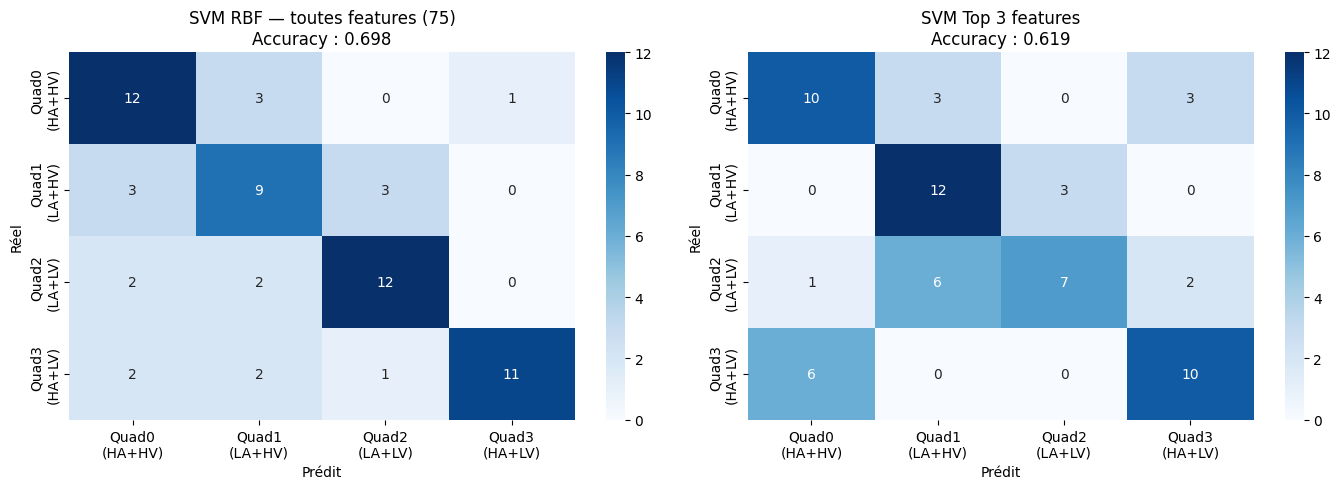

In [100]:
# ============================================
# MATRICE DE CONFUSION — RF Top 3
# ============================================
quad_names = ['Quad0\n(HA+HV)', 'Quad1\n(LA+HV)', 'Quad2\n(LA+LV)', 'Quad3\n(HA+LV)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, name in zip(
    axes,
    [y_pred_svm, y_pred_svm_top3],
    ['SVM RBF — toutes features (75)', 'SVM Top 3 features']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=quad_names, yticklabels=quad_names, ax=ax)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy : {acc:.3f}')
    ax.set_ylabel('Réel')
    ax.set_xlabel('Prédit')

plt.tight_layout()
plt.savefig('confusion_matrices_svm.png', dpi=150)
plt.show()

In [101]:
from sklearn.model_selection import GridSearchCV

# ============================================
# HYPERPARAMETER TUNING — SVM Top 3
# ============================================

# Grille de paramètres
param_grid = {
    'svm__C'      : [0.1, 1, 10, 100],
    'svm__gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1],
    'svm__kernel' : ['rbf', 'poly', 'sigmoid']
}

svm_pipe_top3 = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

grid_search = GridSearchCV(
    svm_pipe_top3,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_final[top3_svm], y_final)

print("=== MEILLEURS HYPERPARAMÈTRES ===")
print(grid_search.best_params_)
print(f"\nMeilleure accuracy CV : {grid_search.best_score_:.3f}")

# Évaluation sur test set
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test[top3_svm])

print("\n=== MÉTRIQUES — SVM Top 3 Tuné ===")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_best):.3f}")
print(f"  Precision : {precision_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"  Recall    : {recall_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_best, average='macro'):.3f}")

# Comparaison avant/après tuning
print("\n=== COMPARAISON AVANT / APRÈS TUNING ===")
print(f"  SVM Top 3 (défaut) : Accuracy = 0.619")
print(f"  SVM Top 3 (tuné)   : Accuracy = {accuracy_score(y_test, y_pred_best):.3f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
=== MEILLEURS HYPERPARAMÈTRES ===
{'svm__C': 100, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

Meilleure accuracy CV : 0.622

=== MÉTRIQUES — SVM Top 3 Tuné ===
  Accuracy  : 0.698
  Precision : 0.727
  Recall    : 0.703
  F1 Score  : 0.682

=== COMPARAISON AVANT / APRÈS TUNING ===
  SVM Top 3 (défaut) : Accuracy = 0.619
  SVM Top 3 (tuné)   : Accuracy = 0.698


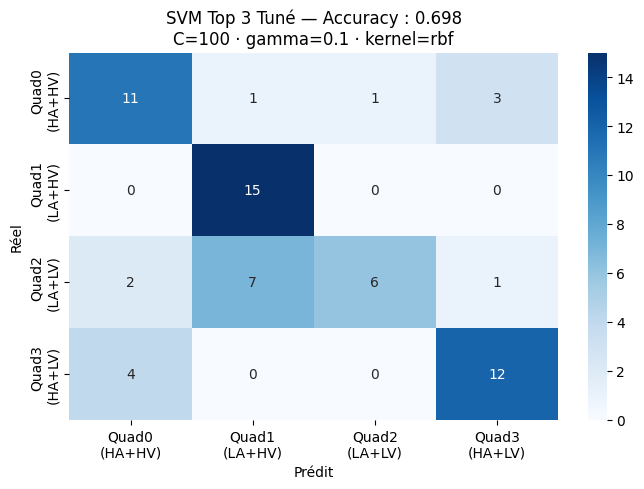

In [102]:
# Matrice de confusion — SVM Top 3 Tuné
quad_names = ['Quad0\n(HA+HV)', 'Quad1\n(LA+HV)', 'Quad2\n(LA+LV)', 'Quad3\n(HA+LV)']

plt.figure(figsize=(7, 5))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=quad_names, yticklabels=quad_names)
plt.title(f'SVM Top 3 Tuné — Accuracy : {accuracy_score(y_test, y_pred_best):.3f}\nC=100 · gamma=0.1 · kernel=rbf')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('confusion_matrix_svm_top3_tuned.png', dpi=150)
plt.show()